In [ ]:
import sys, os
sys.path.insert(0, r"C:\Users\Utente\Desktop\progetto vscode\src")

In [1]:
import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import os
from functions import *
from EDRep import NodeEmbedding   
import random

In [ ]:
def sociopatterns_graph_tot(contacts_file, metadata_file):
    #metadata file
    meta_df = pd.read_csv(metadata_file, sep='\t', header=None, names=['node', 'role', 'gender'])
    role_dict = dict(zip(meta_df['node'], meta_df['role']))
    #contact file
    contacts_df = pd.read_csv(contacts_file, sep=r'\s+', header=None, usecols=[0,1,2], names=['t', 'i', 'j'])
   
    G = nx.Graph()
    for node, role in role_dict.items():
        G.add_node(node, role=role)

    edges_counts = contacts_df.groupby(['i', 'j']).size().reset_index(name='weight')
    
    for _, row in edges_counts.iterrows():
        if row['i'] in G.nodes and row['j'] in G.nodes:
            G.add_edge(row['i'], row['j'], weight=row['weight'])

    return G, role_dict

_SP_DATA = r"C:\Users\Utente\Desktop\progetto vscode\data\socio_patterns"

file_metadati_2011_tot = os.path.join(_SP_DATA, 'highschool_2011.csv', 'highschool_2011_metadata.txt')
file_contatti_2011_tot = os.path.join(_SP_DATA, 'highschool_2011.csv', 'thiers_2011.csv')

file_metadati_2012_tot = os.path.join(_SP_DATA, 'highschool_2012.csv', 'highschool_2012_metadata.txt')
file_contatti_2012_tot = os.path.join(_SP_DATA, 'highschool_2012.csv', 'thiers_2012.csv')

file_metadati_2013_tot = 'HighSchool2013_metadata.txt'
file_contatti_2013_tot = 'High-School_data_2013.csv'


G_2011_tot, roles_2011_tot = sociopatterns_graph_tot(file_contatti_2011_tot, file_metadati_2011_tot)
G_2012_tot, roles_2012_tot= sociopatterns_graph_tot(file_contatti_2012_tot, file_metadati_2012_tot)
G_2013_tot, roles_2013_tot= sociopatterns_graph_tot(file_contatti_2013_tot, file_metadati_2013_tot)

print(f"-> Grafo 2011: {G_2011_tot.number_of_nodes()} studenti, {G_2011_tot.number_of_edges()} archi")
print(f"-> Grafo 2012: {G_2012_tot.number_of_nodes()} studenti, {G_2012_tot.number_of_edges()} archi")
print(f"-> Grafo 2013: {G_2013_tot.number_of_nodes()} studenti, {G_2013_tot.number_of_edges()} archi")

In [ ]:
def sociopatterns_graph(contacts_file, metadata_file):
    #metadata file
    meta_df = pd.read_csv(metadata_file, sep='\t', header=None, names=['node', 'role', 'gender'])
    role_dict = dict(zip(meta_df['node'], meta_df['role']))
    ok_value=['PC*', 'PC', 'PSI*']
    ok_role_dict={c: v for c, v in role_dict.items() if v in ok_value}

    #contact file
    contacts_df = pd.read_csv(contacts_file, sep=r'\s+', header=None, usecols=[0,1,2,3], names=['t', 'i', 'j', 'c_i'])
   
    G = nx.Graph()
    for node, role in ok_role_dict.items():
        G.add_node(node, role=role)

    edges_counts = contacts_df.groupby(['i', 'j']).size().reset_index(name='weight')
    
    for _, row in edges_counts.iterrows():
        if row['i'] in G.nodes and row['j'] in G.nodes:
            G.add_edge(row['i'], row['j'], weight=row['weight'])

    return G, ok_role_dict

file_metadati_2011 = os.path.join(_SP_DATA, 'highschool_2011.csv', 'highschool_2011_metadata.txt')
file_contatti_2011 = os.path.join(_SP_DATA, 'highschool_2011.csv', 'thiers_2011.csv')

file_metadati_2012 = os.path.join(_SP_DATA, 'highschool_2012.csv', 'highschool_2012_metadata.txt')
file_contatti_2012 = os.path.join(_SP_DATA, 'highschool_2012.csv', 'thiers_2012.csv')

file_metadati_2013 = 'HighSchool2013_metadata.txt'
file_contatti_2013 = 'High-School_data_2013.csv'

G_2011, roles_2011 = sociopatterns_graph(file_contatti_2011, file_metadati_2011)
G_2012, roles_2012 = sociopatterns_graph(file_contatti_2012, file_metadati_2012)
G_2013, roles_2013 = sociopatterns_graph(file_contatti_2013, file_metadati_2013)

print(f"-> Grafo 2011: {G_2011.number_of_nodes()} studenti, {G_2011.number_of_edges()} archi")
print(f"-> Grafo 2012: {G_2012.number_of_nodes()} studenti, {G_2012.number_of_edges()} archi")
print(f"-> Grafo 2013: {G_2013.number_of_nodes()} studenti, {G_2013.number_of_edges()} archi")

I have to rename the nodes because otherwise the embedding function won't work

In [4]:

def reset_node_ids(G, roles_dict):
    mapping = {old_node: i for i, old_node in enumerate(G.nodes())}
    
    G_new = nx.relabel_nodes(G, mapping)
    
    roles_new = {mapping[old_node]: role for old_node, role in roles_dict.items()}
    
    return G_new, roles_new

G_2011, roles_2011 = reset_node_ids(G_2011, roles_2011)
G_2012, roles_2012 = reset_node_ids(G_2012, roles_2012)
G_2013, roles_2013 = reset_node_ids(G_2013, roles_2013)

In [5]:
def annual_partition(roles_dict):
    list_PCs = []
    list_PC = []
    list_PSIs = []

    for k,v in roles_dict.items():
        if v == 'PC*':
            list_PCs.append(k)
        elif v == 'PC':
            list_PC.append(k)
        else:
            list_PSIs.append(k)
    return [list_PCs, list_PC, list_PSIs]

In [6]:
partition_2011=annual_partition(roles_2011)
partition_2012=annual_partition(roles_2012)
partition_2013=annual_partition(roles_2013)

In [7]:
emb_2011=node_embedding(G_2011,partition_2011,32)
emb_2012=node_embedding(G_2012,partition_2012,32)
emb_2013=node_embedding(G_2013,partition_2013,32)

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\EDRep\node_embedding.py:35: RuntimeWarning: divide by zero encountered in reciprocal
  D_1 = diags(d**(-1))


In [8]:
d_11_12, vec_11_12, data_11_12= w2_distance_classes(emb_2011,emb_2012)
d_12_13, vec_12_13, data_12_13= w2_distance_classes(emb_2012,emb_2013)
d_11_13, vec_11_13, data_11_13= w2_distance_classes(emb_2011,emb_2013)

In [9]:
print(d_11_12)
print(d_12_13)
print(d_11_13)

0.3441301754568166
0.5910418691470447
0.4706617210625801


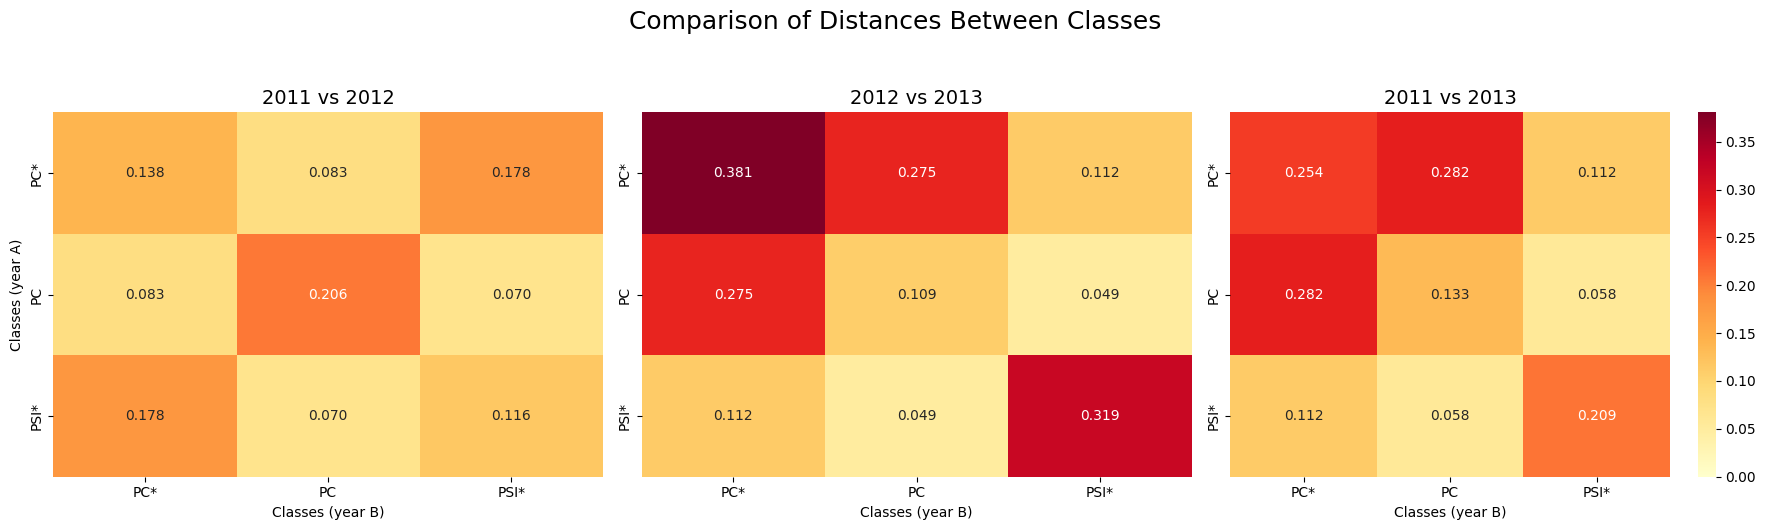

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_multiple_heatmaps(vec_11_12, vec_12_13, vec_11_13, class_names):
    m = len(class_names)
    
    # Funzione interna per convertire il tuo vettore in matrice simmetrica
    def vector_to_matrix(distance_vector):
        matrix = np.zeros((m, m))
        idx = 0
        for i in range(m):
            for j in range(i, m):
                # Gestione per evitare errori se il vettore è più corto del previsto
                if idx < len(distance_vector): 
                    matrix[i, j] = distance_vector[idx]
                    matrix[j, i] = distance_vector[idx]
                    idx += 1
        return matrix

    # Convertiamo i tre vettori
    mat_11_12 = vector_to_matrix(vec_11_12)
    mat_12_13 = vector_to_matrix(vec_12_13)
    mat_11_13 = vector_to_matrix(vec_11_13)
    
    # Setup della figura con 3 subplots affiancati
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Parametri comuni per le heatmap per avere la stessa scala di colori
    # Troviamo il valore massimo tra tutte le matrici per uniformare i colori
    vmax = max(np.max(mat_11_12), np.max(mat_12_13), np.max(mat_11_13))
    
    # Heatmap 1: 2011 vs 2012
    sns.heatmap(mat_11_12, annot=True, cmap="YlOrRd", fmt=".3f", vmin=0, vmax=vmax,
                xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
    axes[0].set_title("2011 vs 2012", fontsize=14)
    axes[0].set_ylabel("Classes (year A)")
    axes[0].set_xlabel("Classes (year B)")
    
    # Heatmap 2: 2012 vs 2013
    sns.heatmap(mat_12_13, annot=True, cmap="YlOrRd", fmt=".3f", vmin=0, vmax=vmax,
                xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False)
    axes[1].set_title("2012 vs 2013", fontsize=14)
    axes[1].set_xlabel("Classes (year B)")
    
    # Heatmap 3: 2011 vs 2013
    sns.heatmap(mat_11_13, annot=True, cmap="YlOrRd", fmt=".3f", vmin=0, vmax=vmax,
                xticklabels=class_names, yticklabels=class_names, ax=axes[2])
    axes[2].set_title("2011 vs 2013", fontsize=14)
    axes[2].set_xlabel("Classes (year B)")
    
    plt.suptitle("Comparison of Distances Between Classes", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

# Esegui la funzione con i vettori e i nomi delle classi
classi = ['PC*', 'PC', 'PSI*']
plot_multiple_heatmaps(vec_11_12, vec_12_13, vec_11_13, classi)

In [ ]:
def shuffle_roles_dict(roles_dict):

    #Takes a dictionary and returns 
    #a new dictionary with the classes randomly shuffled among the nodes.

    nodes = list(roles_dict.keys())
    roles = list(roles_dict.values())
    
    # Mescola casualmente la lista dei ruoli
    random.shuffle(roles)
    
    # Ricrea il dizionario associando i nodi originali ai nuovi ruoli mescolati
    return dict(zip(nodes, roles))

In [ ]:
import numpy as np

# Imposta il numero di permutazioni per il null model (es. 100)
n_permutations = 100
null_distances_11_12 = []

print(f"Calcolo di {n_permutations} permutazioni per il Null Model (2011 vs 2012)...")

for i in range(n_permutations):
    # 1. Crea il dizionario dei ruoli mescolato per il 2012
    shuffled_roles_2012 = shuffle_roles_dict(roles_2012)
    
    # 2. Genera la nuova partizione basata sui ruoli fittizi
    null_partition_2012 = annual_partition(shuffled_roles_2012)
    
    # 3. Ricalcola l'embedding del 2012 usando la partizione nulla (il grafo rimane quello originale!)
    null_emb_2012 = node_embedding(G_2012, null_partition_2012, 16)
    
    # 4. Calcola la distanza tra il 2011 reale e il 2012 nullo
    # (Ignoriamo vec e data con _ per risparmiare memoria)
    d_null, _, _ = w2_distance_classes(emb_2011, null_emb_2012)
    
    null_distances_11_12.append(d_null)

null_distances_11_12 = np.array(null_distances_11_12)

# ==========================================
# RISULTATI E STATISTICA
# ==========================================
mean_null = np.mean(null_distances_11_12)
std_null = np.std(null_distances_11_12)

# Z-score: quanto la tua distanza reale si discosta dalla media casuale
z_score = (d_11_12 - mean_null) / std_null

# p-value: quante distanze nulle sono <= alla distanza reale
p_value = np.sum(null_distances_11_12 <= d_11_12) / n_permutations

print("\n--- RISULTATI 2011 vs 2012 ---")
print(f"Distanza reale d(2011, 2012): {d_11_12:.4f}")
print(f"Distanza media Null Model:   {mean_null:.4f} ± {std_null:.4f}")
print(f"Z-score: {z_score:.2f}")
print(f"p-value: {p_value:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Disegna la distribuzione del Null Model
sns.histplot(null_distances_11_12, kde=True, color="skyblue", bins=15, label="Null Model Distances")

# Disegna una linea rossa per la tua distanza reale
plt.axvline(x=d_11_12, color="red", linestyle="--", linewidth=2, label=f"Real Distance: {d_11_12:.4f}")

plt.title("Real Distance vs Null Model Distribution (2011 vs 2012)")
plt.xlabel("Wasserstein Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_temporal_activity(contacts_file):
    df = pd.read_csv(contacts_file, sep=r'\s+', header=None, usecols=[0,1,2], names=['t', 'i', 'j'])
    df['datetime'] = pd.to_datetime(df['t'], unit='s')
    df['time_window'] = df['datetime'].dt.floor('10min')
    activity = df.groupby('time_window').size()
    
    plt.figure(figsize=(14, 5))
    activity.plot(color='teal', linewidth=2)
    plt.title('Ritmo circadiano della scuola: Volume dei contatti nel tempo', fontsize=14)
    plt.xlabel('Giorno e Ora', fontsize=12)
    plt.ylabel('Numero di contatti (ogni 10 min)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_temporal_activity(file_contatti_2012_tot)